In [1]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord, Angle
from astropy.table import Table, vstack
from astropy.time import Time
from astropy.io import fits
from regions import CircleSkyRegion
import matplotlib.pyplot as plt
import multiprocessing as mp
import pandas as pd
import os
import glob
from scipy.stats import halfnorm
from scipy.integrate import quad
from scipy.optimize import curve_fit
from collections import OrderedDict

# %matplotlib inline
from pathlib import Path
from IPython.display import display
from gammapy.data import FixedPointingInfo, Observation, observatory_locations, DataStore, ObservationTable, EventList, PointingInfo, GTI
from gammapy.analysis import Analysis, AnalysisConfig
from gammapy.datasets import Datasets, FluxPointsDataset, SpectrumDataset, SpectrumDatasetOnOff, MapDataset, MapDatasetEventSampler
from gammapy.irf import load_irf_dict_from_file, EDispKernelMap, EffectiveAreaTable2D, Background3D, BackgroundIRF, FoVAlignment
from gammapy.estimators import ASmoothMapEstimator, TSMapEstimator, FluxPointsEstimator
from gammapy.makers import MapDatasetMaker, SafeMaskMaker, ReflectedRegionsBackgroundMaker, SpectrumDatasetMaker
from gammapy.makers.utils import make_theta_squared_table
from gammapy.estimators.utils import find_peaks, find_peaks_in_flux_map, resample_energy_edges
from gammapy.maps import MapAxis, WcsGeom, RegionGeom, Map
from gammapy.estimators import ExcessMapEstimator, LightCurveEstimator
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    PointSpatialModel,
    FoVBackgroundModel,
    GaussianSpatialModel,
    LogParabolaSpectralModel,
    LogParabolaNormSpectralModel,
    Models,
    ExpCutoffPowerLawSpectralModel,
    PowerLawSpectralModel,
    SkyModel,
    TemplateSpectralModel,
    ExpCutoffPowerLawNormSpectralModel,
    CompoundSpectralModel,
    SmoothBrokenPowerLawSpectralModel,
)
from gammapy.visualization import plot_distribution
from regions import CircleSkyRegion
from gammapy.modeling import Parameter, Parameters
from gammapy.modeling.models import SpectralModel, PowerLawSpectralModel 
from scipy.optimize import curve_fit

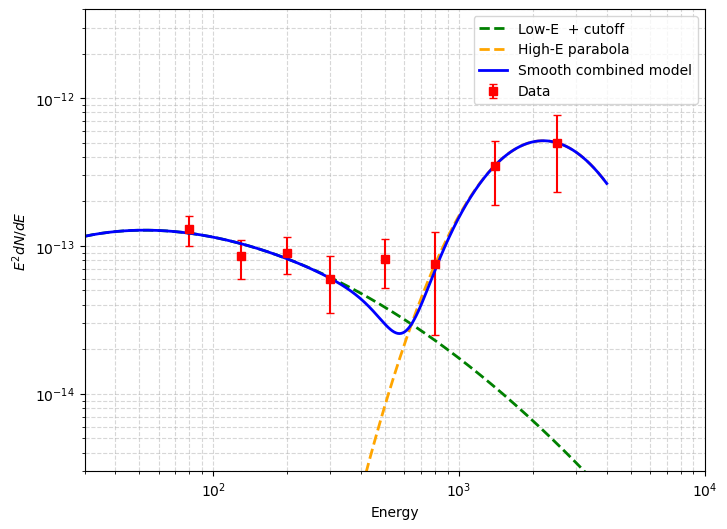

LOW ENERGY MODEL
a        = 0.429
logEp    = 1.500
Ep       = 31.6
Ec (cut) = 10.0


In [2]:
# ======================
# DATI
# ======================
energy_value = np.array([80, 130, 200, 300, 500, 800, 1400, 2500])
e2dnde_value = np.array([
    1.3e-13, 8.5e-14, 9.0e-14, 6.0e-14,
    8.2e-14, 7.5e-14, 3.5e-13, 5.0e-13
])
err_value = np.array([
    0.3e-13, 0.25e-13, 0.25e-13, 0.25e-13,
    0.3e-13, 0.5e-13, 1.6e-13, 2.7e-13
])

# ======================
# MODELLI
# ======================

# HIGH energy: parabola normale
def logparabola_high(logE, a, b, c):
    return a * logE**2 + b * logE + c

# LOW energy: parabola concava + cutoff a basse E
def logparabola_low_cut(logE, a, logEp, c, Ec):
    E = 10**logE
    return (
        -a * (logE - logEp)**2
        + c
        - Ec / (E * np.log(10))
    )

# ======================
# DATI IN LOG
# ======================
logE = np.log10(energy_value)
logY = np.log10(e2dnde_value)

logErr = err_value / (e2dnde_value * np.log(10))

# ======================
# FIT LOW ENERGY (CUT-OFF + CONCAVITÀ OPPOSTA)
# ======================
p0_low = [1.0, np.log10(200), -13, 200]
bounds_low = (
    [0.01, 1.5, -16, 10],
    [10.0, 3.5, -10, 2000]
)

popt_low, _ = curve_fit(
    logparabola_low_cut,
    logE[:4],
    logY[:4],
    sigma=logErr[:4],
    p0=p0_low,
    bounds=bounds_low,
    absolute_sigma=True,
    maxfev=20000
)

# ======================
# FIT HIGH ENERGY
# ======================
popt_high, _ = curve_fit(
    logparabola_high,
    logE[5:],
    logY[5:],
    sigma=logErr[5:],
    absolute_sigma=True
)

# ======================
# MODELLO COMBINATO LISCIO
# ======================
def smooth_combined(E, Etrans=600, width=0.05):
    logE = np.log10(E)

    f_low = 10**logparabola_low_cut(logE, *popt_low)
    f_high = 10**logparabola_high(logE, *popt_high)

    x = (logE - np.log10(Etrans)) / width
    S = 1.0 / (1.0 + np.exp(-x))

    return f_low**(1 - S) * f_high**S

# ======================
# PLOT
# ======================
energy_fit = np.logspace(np.log10(30), np.log10(4000), 600)

plt.figure(figsize=(8, 6))

plt.errorbar(
    energy_value, e2dnde_value, yerr=err_value,
    fmt='s', color='red', capsize=3, label='Data'
)

plt.loglog(
    energy_fit,
    10**logparabola_low_cut(np.log10(energy_fit), *popt_low),
    '--', lw=2, color='green', label='Low-E  + cutoff'
)

plt.loglog(
    energy_fit,
    10**logparabola_high(np.log10(energy_fit), *popt_high),
    '--', lw=2, color='orange', label='High-E parabola'
)

plt.loglog(
    energy_fit,
    smooth_combined(energy_fit),
    '-', lw=2, color='blue', label='Smooth combined model'
)

plt.xlabel("Energy")
plt.ylabel(r"$E^2 dN/dE$")
plt.grid(which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.xlim(30, 1e4)
plt.ylim(3e-15, 4e-12)
plt.show()

# ======================
# PARAMETRI
# ======================
a, logEp, c, Ec = popt_low
print("LOW ENERGY MODEL")
print(f"a        = {a:.3f}")
print(f"logEp    = {logEp:.3f}")
print(f"Ep       = {10**logEp:.1f}")
print(f"Ec (cut) = {Ec:.1f}")


components:
-   name: Cygnus X3 - bump
    type: SkyModel
    spectral:
        type: LogParabolaSpectralModel
        parameters:
        -   name: amplitude
            value: 8.0e-20
            unit: TeV-1 s-1 cm-2
        -   name: reference
            value: 2250.0
            unit: TeV
        -   name: alpha
            value: 2.2
        -   name: beta
            value: 3.0
    spatial:
        type: PointSpatialModel
        frame: icrs
        parameters:
        -   name: lon_0
            value: 79.81177166149858
            unit: deg
        -   name: lat_0
            value: 0.6821723563705961
            unit: deg
metadata:
    creator: Gammapy 1.3
    date: '2026-02-14T19:55:17.598987'
    origin: null



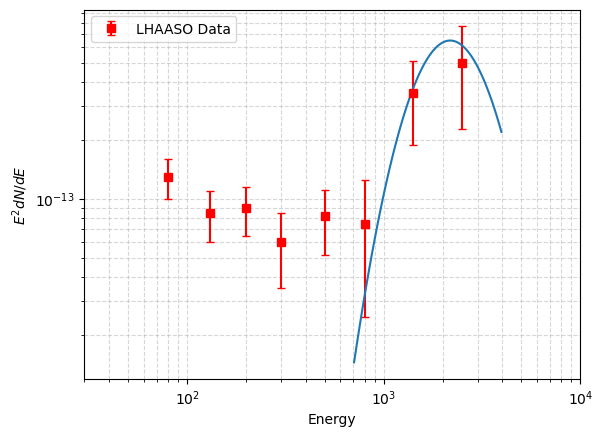

In [79]:
energy_value = np.array([80, 130, 200, 300, 500, 800, 1400, 2500])
e2dnde_value = np.array([
    1.3e-13, 8.5e-14, 9.0e-14, 6.0e-14,
    8.2e-14, 7.5e-14, 3.5e-13, 5.0e-13
])
err_value = np.array([
    0.3e-13, 0.25e-13, 0.25e-13, 0.25e-13,
    0.3e-13, 0.5e-13, 1.6e-13, 2.7e-13
])
plt.errorbar(
    energy_value, e2dnde_value, yerr=err_value,
    fmt='s', color='red', capsize=3, label='LHAASO Data'
)
model = LogParabolaSpectralModel(
    alpha=2.2,
    amplitude="8e-20 cm-2 s-1 TeV-1",
    reference=2250 * u.TeV,
    beta=3,
)
energy_bounds = [700,4000] * u.TeV
model.plot(energy_bounds,sed_type='e2dnde')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Energy")
plt.ylabel(r"$E^2 dN/dE$")
plt.grid(which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.xlim(30, 1e4)
#plt.ylim(3e-15, 4e-12)

pnt = PointSpatialModel(lon_0=79.81177166149858 *u.deg, lat_0= 0.6821723563705961*u.deg)
gammacygni = SkyModel(spatial_model=pnt,  spectral_model=model, name="Cygnus X3 - bump")
models = Models([gammacygni])

print(models.to_yaml())
models.write("X3_bump.yaml", overwrite=True)
import os

# Cartella di destinazione
folder = "/Users/camillaquartiroli/Desktop/GAMMAPY/Notebook/Cygnus/plot_modelli"

# Crea la cartella se non esiste
os.makedirs(folder, exist_ok=True)

# Salvataggio del file
plt.savefig(os.path.join(folder, "X3_bump.png"), dpi=300)
plt.show()

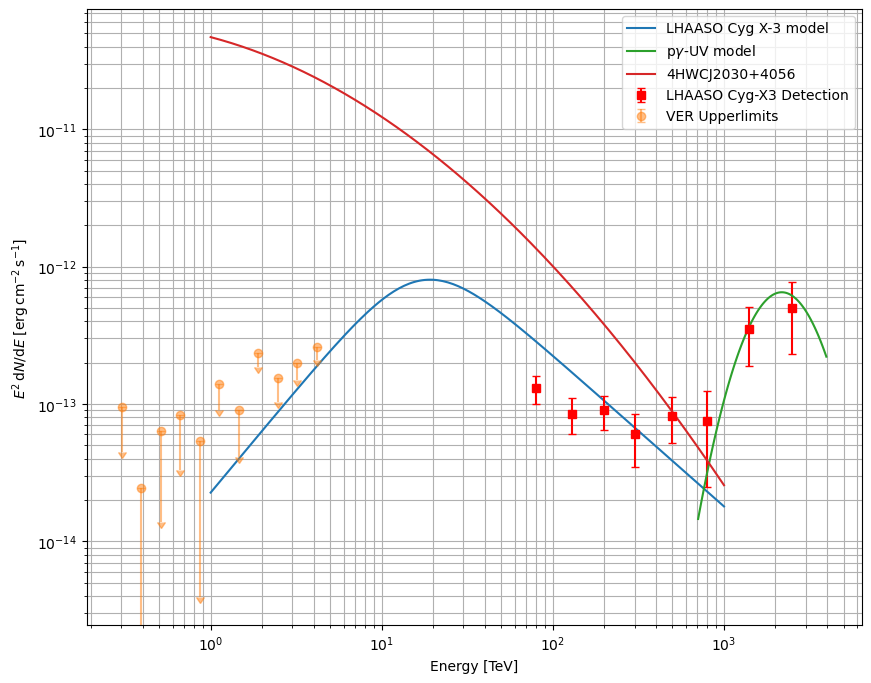

In [117]:
plt.figure(figsize=(10,  8))
# --- Bins energy (TeV) ---
energy_bins = [
    (0.263,0.342),
    (0.342,0.445),
    (0.445,0.578),
    (0.578,0.751),
    (0.751,0.977),
    (0.977,1.269),
    (1.269,1.650),
    (1.650,2.145),
    (2.145,2.789),
    (2.789,3.626),
    (3.626,4.713)
]

# centro e larghezza del bin
energy_center = [(e1 + e2) / 2 for e1, e2 in energy_bins]      # TeV
energy_width  = [e2 - e1 for e1, e2 in energy_bins]            # TeV

# --- Flux upper limit integrato nel bin ---
# (10^-12 ph cm^-2 s^-1)
flux_ul_photon = [0.5, 0.1, 0.2, 0.2, 0.1, 0.2, 0.1, 0.2, 0.1, 0.1, 0.1]

# flusso differenziale in fotoni
# ph cm^-2 s^-1 TeV^-1
flux_ul_diff = [
    f * 1e-12 / w
    for f, w in zip(flux_ul_photon, energy_width)
]

# flusso energetico differenziale
# TeV cm^-2 s^-1 TeV^-1
flux_ul_energy_diff = [
    E * f
    for E, f in zip(energy_center, flux_ul_diff)
]

# flusso energetico integrato nel bin
# TeV cm^-2 s^-1
flux_ul_energy_bin = [
    E * f * w
    for E, f, w in zip(energy_center, flux_ul_diff, energy_width)
]
# trasformiamo in Quantity con unità TeV cm^-2 s^-1
flux_ul_energy_bin = u.Quantity(flux_ul_energy_bin, unit=u.erg / (u.cm**2 * u.s))

# adesso possiamo convertire in erg cm^-2 s^-1
flux_ul_energy_bin = flux_ul_energy_bin.to(u.TeV / (u.cm**2 * u.s))



# Modello
model = SmoothBrokenPowerLawSpectralModel(
    index1=0.5,
    index2=3.1, #2.5
    amplitude="2e-15TeV-1 cm-2 s-1", #5
    ebreak="17 TeV",
    reference="50 TeV",
    beta=1,
)


# Energia per il modello
energy = np.logspace(np.log10(1), np.log10(1e3), 200) * u.TeV
dnde = model(energy)
#e2dnde_model = (energy**2 * dnde).to("TeV cm-2 s-1")

e2dnde = (energy**2 * dnde).to("erg cm-2 s-1")

# Plot
plt.loglog(
    energy,
    e2dnde,
    label="LHAASO Cyg X-3 model"
)
plt.errorbar(
    energy_value,
    e2dnde_value,
    yerr=err_value,
    fmt='s',          # marker quadrato (come nel plot)
    color='red',
    ecolor='red',     # colore delle barre di errore
    capsize=3,        # cappucci
    linestyle='none',# niente linee di collegamento
    label = "LHAASO Cyg-X3 Detection"
)
"""
plt.loglog(
    energy_center,
    flux_ul_energy_bin,
    marker='o',
    linestyle='None'
)
"""
uplims = np.array([1, 1,1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=bool)

plt.errorbar(
    energy_center,
    flux_ul_energy_bin.value,
    yerr= 5e-14,  # lunghezza freccina (scegli tu la scala)
    uplims=uplims,
    fmt='o',
    capsize=3, 
    alpha = 0.5, 
    label = "VER Upperlimits"
)

energy_bounds_HWC = [1, 25] * u.TeV
model_HWC = LogParabolaSpectralModel(
    alpha=2.48,
    amplitude="55.3e-13 TeV-1 cm-2 s-1",
    reference=2* u.TeV,
    beta = 0.11
)

energy_HWC= np.logspace(np.log10(1), np.log10(1e3), 200) * u.TeV


dnde_HWC = model_HWC(energy_HWC)
e2dnde_HWC = (energy_HWC**2 * dnde_HWC).to("erg cm-2 s-1")

energy_bounds_LHAASO = [1, 25] * u.TeV
model_LHAASO = PowerLawSpectralModel(
    index=2.81,
    amplitude="0.77e-13 TeV-1 cm-2 s-1",
    reference=3* u.TeV
)

energy_LHAASO= np.logspace(np.log10(1), np.log10(1e3), 200) * u.TeV


dnde_LHAASO = model_LHAASO(energy_LHAASO)
e2dnde_LHAASO = (energy_LHAASO**2 * dnde_LHAASO).to("erg cm-2 s-1")

model_bump = LogParabolaSpectralModel(
    alpha=2.2,
    amplitude="8e-20 cm-2 s-1 TeV-1",
    reference=2250 * u.TeV,
    beta=3,
)
energy_bounds = [700,4000] * u.TeV
model_bump.plot(energy_bounds, sed_type='e2dnde', label=r"p$\gamma$-UV model")
plt.loglog(energy_HWC, e2dnde_HWC, label="4HWCJ2030+4056")
#plt.loglog(energy_LHAASO, e2dnde_LHAASO, label="LHAASO ")

plt.xlabel("Energy [TeV]")
plt.ylabel(r"$E^2\,\mathrm{d}N/\mathrm{d}E\;[\mathrm{erg\,cm^{-2}\,s^{-1}}]$")
plt.grid(which="both")
plt.legend(fontsize = 14)
#plt.ylim(1e-14, 1e-12)
#plt.xlim(1, 10**4)
plt.legend()

import os

# Cartella di destinazione
folder = "/Users/camillaquartiroli/Desktop/GAMMAPY/Notebook/Cygnus/plot_modelli"

# Crea la cartella se non esiste
os.makedirs(folder, exist_ok=True)

# Salvataggio del file
plt.savefig(os.path.join(folder, "CygnusX3.png"), dpi=300)
plt.show()



In [8]:
ra = 308.10 * u.deg
dec = 40.92 * u.deg

c = SkyCoord(ra=ra, dec=dec, frame='icrs')

lon = c.galactic.l.deg * u.deg
lat = c.galactic.b.deg * u.deg

print(lon, lat)


gauss = GaussianSpatialModel(lon_0=lon, lat_0=lat, sigma="0.16 deg")
OB2model = SkyModel(spatial_model=gauss,  spectral_model=model, name="LHAASO Cygnus X3")
models = Models([OB2model])

print(models.to_yaml())
models.write("X3_model_provaa.yaml", overwrite=True)

79.81177166149858 deg 0.6821723563705961 deg
components:
-   name: LHAASO Cygnus X3
    type: SkyModel
    spectral:
        type: SmoothBrokenPowerLawSpectralModel
        parameters:
        -   name: index1
            value: 1.0
        -   name: index2
            value: 2.5
        -   name: amplitude
            value: 5.0e-16
            unit: TeV-1 s-1 cm-2
        -   name: ebreak
            value: 10.0
            unit: TeV
        -   name: reference
            value: 50.0
            unit: TeV
        -   name: beta
            value: 1.0
    spatial:
        type: GaussianSpatialModel
        frame: icrs
        parameters:
        -   name: lon_0
            value: 79.81177166149858
            unit: deg
        -   name: lat_0
            value: 0.6821723563705961
            unit: deg
        -   name: sigma
            value: 0.16
            unit: deg
        -   name: e
            value: 0.0
        -   name: phi
            value: 0.0
            unit: deg
metad

In [32]:
ra = 307.90 * u.deg
dec = 40.88 * u.deg

c = SkyCoord(ra=ra, dec=dec, frame='icrs')

lon = c.galactic.l.deg * u.deg
lat = c.galactic.b.deg * u.deg

print(lon, lat)

79.68999900667215 deg 0.7802866009425939 deg


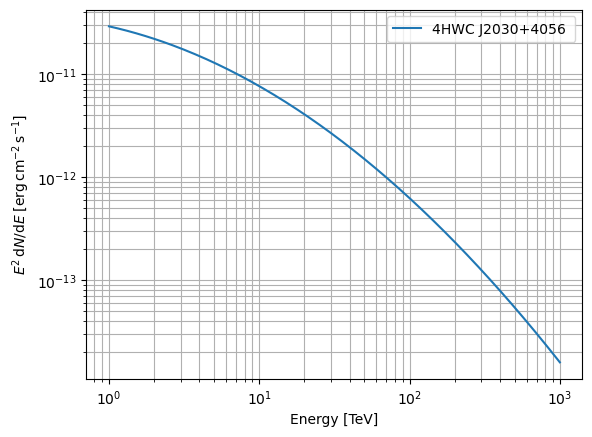

In [14]:
model_HWC = LogParabolaSpectralModel(
    alpha=2.48,
    amplitude="55.3e-13 TeV-1 cm-2 s-1",
    reference=2* u.TeV,
    beta = 0.11
)

energy_HWC= np.logspace(np.log10(1), np.log10(1e3), 200) * u.TeV


dnde_HWC = model_HWC(energy_HWC)
e2dnde_HWC = (energy_HWC**2 * dnde_HWC).to("TeV cm-2 s-1")

plt.loglog(energy_HWC, e2dnde_HWC, label="4HWC J2030+4056 ")

plt.xlabel("Energy [TeV]")
plt.ylabel(r"$E^2\,\mathrm{d}N/\mathrm{d}E\;[\mathrm{erg\,cm^{-2}\,s^{-1}}]$")
plt.grid(which="both")
plt.legend()
#plt.ylim(1e-14, 1e-12)
#plt.xlim(1, 10**4)
plt.legend()
plt.show()